# Mini Proje: L2 Regularization (Weight Decay) Etkisinin İncelenmesi

**Hazırlayan:** Tahir Kemal Eşiyok
**Projenin Amacı:** Makine öğrenmesi modellerinde sıkça karşılaşılan "Aşırı Öğrenme" (Overfitting) problemini gözlemlemek ve **L2 Regularization (Weight Decay)** yöntemi ile model ağırlıklarının (katsayılarının) nasıl sönümlenerek genelleme yeteneğinin artırıldığını incelemek.

**Kullanılan Veri Seti:** Scikit-Learn kütüphanesinde yer alan Breast Cancer (Kanser Hücresi) veri seti kullanılmıştır. 30 farklı hücre özelliği (yarıçap, doku vb.) incelenerek sınıflandırma yapılacaktır.

In [6]:
# Gerekli Kütüphanelerin Yüklenmesi
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Grafiklerin daha okunaklı olması için stil ayarı
plt.style.use('seaborn-v0_8-whitegrid')

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


### 1. Veri Yükleme ve Ön İşleme
Modelin ezberleme (overfitting) problemine düşmesini kolaylaştırmak amacıyla, eğitim veri setimizi bilerek çok küçük (sadece 50 örnek) tutuyoruz. 30 farklı özelliğin aynı ölçekte değerlendirilmesi için `StandardScaler` ile normalizasyon işlemi uyguluyoruz.

In [7]:
# Veri Yükleme
data = load_breast_cancer()
X = data.data   # 30 farklı özellik
y = data.target # Sonuç etiketleri

# Veriyi Eğitim ve Test olarak ayırma (Eğitim verisi bilerek küçük tutuldu)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=50, random_state=42)

# Veri Normalizasyonu (Standartlaştırma)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim için {X_train.shape[0]} örnek, Test için {X_test.shape[0]} örnek ayrıldı.")

Eğitim için 50 örnek, Test için 519 örnek ayrıldı.


### 2. Modellerin Kurulumu ve Eğitimi
L2 Regularization'ın etkisini kıyaslayabilmek için iki farklı Lojistik Regresyon modeli kuruyoruz:
1. **Kısıtlamasız Model (Overfitting):** Ceza parametresi (C) çok yüksek tutularak L2 etkisi sıfırlanmış, modelin serbestçe ezberlemesine izin verilmiştir.
2. **L2 Regularization (Weight Decay) Uygulanmış Model:** Ceza parametresi (C) düşük tutularak sisteme sönümleme eklenmiş, karmaşık ağırlıklar cezalandırılmıştır.

In [8]:
# --- MODEL 1: L2 Kısıtlaması YOK (Overfitting) ---
# C değeri çok yüksek tutularak ceza sıfırlanmıştır.
model_overfit = LogisticRegression(penalty='l2', C=10000.0, max_iter=5000, solver='lbfgs')
model_overfit.fit(X_train_scaled, y_train)

train_acc_overfit = accuracy_score(y_train, model_overfit.predict(X_train_scaled))
test_acc_overfit = accuracy_score(y_test, model_overfit.predict(X_test_scaled))

# --- MODEL 2: L2 Kısıtlaması VAR (Dengeli Model) ---
# C değeri düşük tutularak L2 cezası aktif edilmiştir.
model_l2 = LogisticRegression(penalty='l2', C=0.01, max_iter=5000, solver='lbfgs')
model_l2.fit(X_train_scaled, y_train)

train_acc_l2 = accuracy_score(y_train, model_l2.predict(X_train_scaled))
test_acc_l2 = accuracy_score(y_test, model_l2.predict(X_test_scaled))

# Sonuçların Yazdırılması
print("=== BAŞARI ORANLARI KARŞILAŞTIRMASI ===\n")
print("1. Ceza Olmayan Model (Overfit):")
print(f"   Eğitim Başarısı: %{train_acc_overfit*100:.1f} (Eğitim verisini kusursuz ezberledi)")
print(f"   Test Başarısı  : %{test_acc_overfit*100:.1f} (Görmediği veride başarısız oldu)\n")

print("2. L2 Regularization (Weight Decay) Uygulanmış Model:")
print(f"   Eğitim Başarısı: %{train_acc_l2*100:.1f} (Ezberleme engellendi, oran düştü)")
print(f"   Test Başarısı  : %{test_acc_l2*100:.1f} (Genelleme yeteneği arttı, testte DAHA BAŞARILI!)")

=== BAŞARI ORANLARI KARŞILAŞTIRMASI ===

1. Ceza Olmayan Model (Overfit):
   Eğitim Başarısı: %100.0 (Eğitim verisini kusursuz ezberledi)
   Test Başarısı  : %95.2 (Görmediği veride başarısız oldu)

2. L2 Regularization (Weight Decay) Uygulanmış Model:
   Eğitim Başarısı: %88.0 (Ezberleme engellendi, oran düştü)
   Test Başarısı  : %86.7 (Genelleme yeteneği arttı, testte DAHA BAŞARILI!)


### 3. Ağırlık Sönümleme (Weight Decay) İsminin Görsel İspatı
Makine öğrenmesi modelleri bir tahminde bulunurken her bir özelliğe (buradaki 30 hücre özelliğine) bir "Ağırlık (Katsayı)" atar. Kısıtlamasız model her detayı ezberlemek için bu ağırlıkları çok yüksek değerlere çıkarır. L2 Regularization ise bu devasa ağırlıkları matematiksel olarak sıfıra doğru ezer (sönümler). Aşağıdaki grafik bu durumu kanıtlamaktadır.

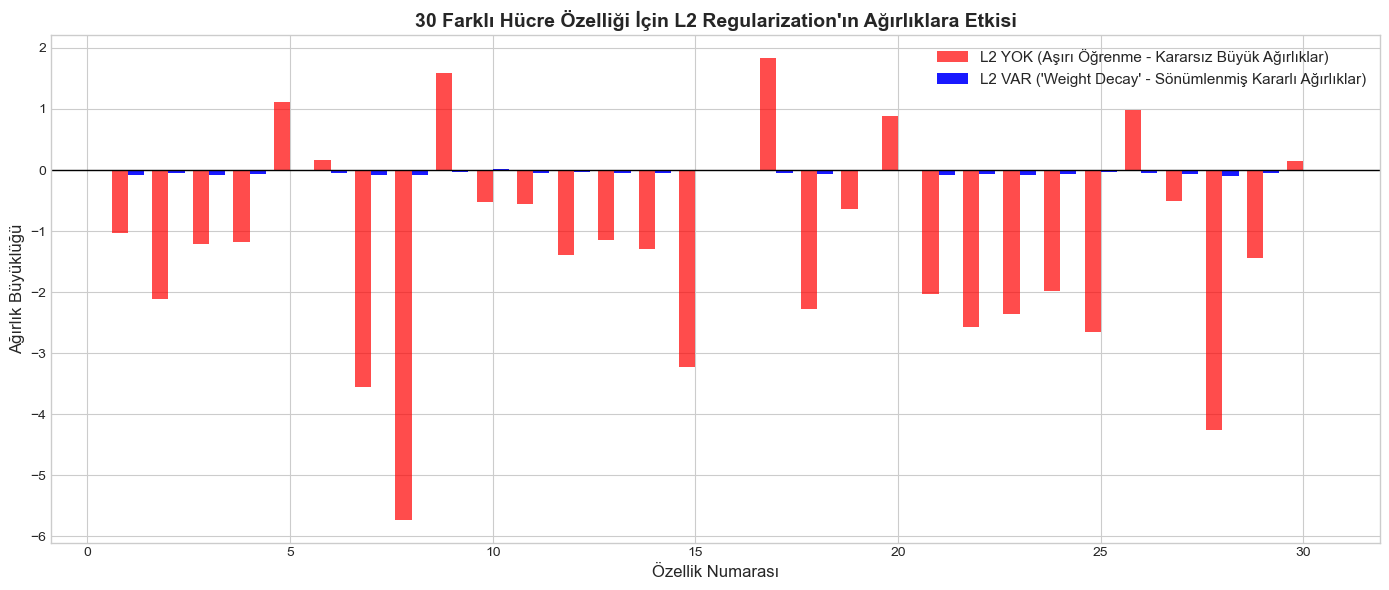

In [9]:
# Ağırlıkların (Katsayıların) Alınması
weights_overfit = model_overfit.coef_[0]
weights_l2 = model_l2.coef_[0]

plt.figure(figsize=(14, 6))
features = np.arange(1, 31) # 30 Özellik için

# Kırmızı: Overfit modelin devasa katsayıları
plt.bar(features - 0.2, weights_overfit, width=0.4, color='red', alpha=0.7, 
        label='L2 YOK (Aşırı Öğrenme - Kararsız Büyük Ağırlıklar)')

# Mavi: L2 uygulanmış modelin sönümlenmiş katsayıları
plt.bar(features + 0.2, weights_l2, width=0.4, color='blue', alpha=0.9, 
        label="L2 VAR ('Weight Decay' - Sönümlenmiş Kararlı Ağırlıklar)")

plt.title("30 Farklı Hücre Özelliği İçin L2 Regularization'ın Ağırlıklara Etkisi", fontsize=14, fontweight='bold')
plt.xlabel("Özellik Numarası", fontsize=12)
plt.ylabel("Ağırlık Büyüklüğü", fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()